In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

In [ ]:
class SRDataset(Dataset):
    """Paired LR-HR dataset for super-resolution"""
    def __init__(self, data_dir):
        self.hr_dir = os.path.join(data_dir, 'HR')
        self.lr_dir = os.path.join(data_dir, 'LR')

        self.hr_files = sorted([f for f in os.listdir(self.hr_dir) if f.endswith('.npy')])
        self.lr_files = sorted([f for f in os.listdir(self.lr_dir) if f.endswith('.npy')])

        assert len(self.hr_files) == len(self.lr_files), "HR and LR count mismatch"

    def __len__(self):
        return len(self.hr_files)

    def __getitem__(self, idx):
        hr = np.load(os.path.join(self.hr_dir, self.hr_files[idx])).astype(np.float32)  # (1, 150, 150)
        lr = np.load(os.path.join(self.lr_dir, self.lr_files[idx])).astype(np.float32)  # (1, 75, 75)

        hr = torch.tensor(hr)
        lr = torch.tensor(lr)

        return lr, hr

dataset = SRDataset('/content/Dataset')

train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train: {train_size}, Test: {test_size}")

Train: 9000, Test: 1000


In [ ]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=1, embed_dim=256):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

In [ ]:
class MAESuperResolution(nn.Module):
    """Super-resolution model using pre-trained MAE encoder"""
    def __init__(self, encoder_dim=256, encoder_depth=6, encoder_heads=4):
        super().__init__()

        # Pre-trained encoder components (will load weights)
        self.patch_embed = PatchEmbed(64, 8, 1, encoder_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, encoder_dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, 65, encoder_dim) * 0.02)  # 64 patches + 1 cls
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(encoder_dim, encoder_heads) for _ in range(encoder_depth)
        ])
        self.encoder_norm = nn.LayerNorm(encoder_dim)

        # New SR decoder
        # Transform encoder output (64 patches × 256 dim) → spatial features
        self.decoder_proj = nn.Linear(encoder_dim, 512)

        # Reshape to spatial: 8×8 × 512 channels
        # Upsample: 8→16→32→64→128→150
        self.decoder = nn.Sequential(
            # 8×8 → 16×16
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            # 16×16 → 32×32
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            # 32×32 → 64×64
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            # 64×64 → 128×128
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            # 128×128 → 150×150
            nn.Conv2d(64, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Upsample(size=(150, 150), mode='bilinear', align_corners=False),

            # Final refinement
            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        """Encode using pre-trained MAE encoder"""
        # Resize LR input to 64×64 for encoder
        x = F.interpolate(x, size=(64, 64), mode='bilinear', align_corners=False)

        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]

        cls = self.cls_token + self.pos_embed[:, :1, :]
        cls = cls.expand(x.shape[0], -1, -1)
        x = torch.cat([cls, x], dim=1)

        for block in self.encoder_blocks:
            x = block(x)
        x = self.encoder_norm(x)

        return x[:, 1:, :]  # skip cls token, return patch features

    def forward(self, lr):
        # Encode
        features = self.encode(lr)  # (B, 64, 256)

        # Project
        features = self.decoder_proj(features)  # (B, 64, 512)

        # Reshape to spatial: (B, 512, 8, 8)
        B = features.shape[0]
        features = features.transpose(1, 2).reshape(B, 512, 8, 8)

        # Decode to HR
        hr_pred = self.decoder(features)  # (B, 1, 150, 150)

        return hr_pred


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sr_model = MAESuperResolution().to(device)

# Load pre-trained MAE encoder weights
mae_weights = torch.load('/content/mae_pretrained.pth', map_location=device)
encoder_keys = {k: v for k, v in mae_weights.items()
                if any(k.startswith(prefix) for prefix in
                       ['patch_embed', 'cls_token', 'pos_embed', 'encoder_blocks', 'encoder_norm'])}

missing, unexpected = sr_model.load_state_dict(encoder_keys, strict=False)
print(f"Loaded pre-trained encoder weights")
print(f"New decoder layers (expected): {len(missing)}")
print(f"Model parameters: {sum(p.numel() for p in sr_model.parameters()):,}")

Loaded pre-trained encoder weights
New decoder layers (expected): 34
Model parameters: 8,833,473


In [ ]:
def compute_psnr(pred, target):
    """Peak Signal-to-Noise Ratio"""
    mse = F.mse_loss(pred, target)
    if mse == 0:
        return float('inf')
    return 10 * torch.log10(1.0 / mse)


def compute_ssim(pred, target, window_size=11):
    """Simplified SSIM computation"""
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    # Create gaussian window
    sigma = 1.5
    coords = torch.arange(window_size, dtype=torch.float32, device=pred.device) - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    window = (g.unsqueeze(1) * g.unsqueeze(0))
    window = window / window.sum()
    window = window.unsqueeze(0).unsqueeze(0)  # (1, 1, 11, 11)

    mu1 = F.conv2d(pred, window, padding=window_size // 2)
    mu2 = F.conv2d(target, window, padding=window_size // 2)

    mu1_sq = mu1 ** 2
    mu2_sq = mu2 ** 2
    mu1_mu2 = mu1 * mu2

    sigma1_sq = F.conv2d(pred ** 2, window, padding=window_size // 2) - mu1_sq
    sigma2_sq = F.conv2d(target ** 2, window, padding=window_size // 2) - mu2_sq
    sigma12 = F.conv2d(pred * target, window, padding=window_size // 2) - mu1_mu2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

    return ssim_map.mean()

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(sr_model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

num_epochs = 30

for epoch in range(num_epochs):
    sr_model.train()
    running_loss = 0.0
    running_psnr = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for lr_imgs, hr_imgs in pbar:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)

        optimizer.zero_grad()
        hr_pred = sr_model(lr_imgs)
        loss = criterion(hr_pred, hr_imgs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        with torch.no_grad():
            psnr = compute_psnr(hr_pred, hr_imgs)
            running_psnr += psnr.item()

        pbar.set_postfix({
            'loss': f'{loss.item():.6f}',
            'psnr': f'{psnr.item():.2f}dB'
        })

    scheduler.step()
    avg_loss = running_loss / len(train_loader)
    avg_psnr = running_psnr / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - MSE: {avg_loss:.6f} - PSNR: {avg_psnr:.2f}dB\n")

Epoch 1/30: 100%|██████████| 282/282 [00:39<00:00,  7.07it/s, loss=0.006842, psnr=21.65dB]


Epoch 1/30 - MSE: 0.041066 - PSNR: 15.87dB



Epoch 2/30: 100%|██████████| 282/282 [00:39<00:00,  7.08it/s, loss=0.001643, psnr=27.84dB]


Epoch 2/30 - MSE: 0.003062 - PSNR: 25.53dB



Epoch 3/30: 100%|██████████| 282/282 [00:42<00:00,  6.59it/s, loss=0.000727, psnr=31.39dB]


...

Epoch 28/30 - MSE: 0.000097 - PSNR: 40.16dB



Epoch 29/30: 100%|██████████| 282/282 [00:42<00:00,  6.69it/s, loss=0.000099, psnr=40.06dB]


Epoch 29/30 - MSE: 0.000096 - PSNR: 40.18dB



Epoch 30/30: 100%|██████████| 282/282 [00:42<00:00,  6.69it/s, loss=0.000107, psnr=39.69dB]

Epoch 30/30 - MSE: 0.000095 - PSNR: 40.21dB



In [ ]:
sr_model.eval()
total_mse = 0.0
total_ssim = 0.0
total_psnr = 0.0
num_batches = 0

with torch.no_grad():
    for lr_imgs, hr_imgs in tqdm(test_loader, desc="Evaluating"):
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        hr_pred = sr_model(lr_imgs)

        total_mse += F.mse_loss(hr_pred, hr_imgs).item()
        total_ssim += compute_ssim(hr_pred, hr_imgs).item()
        total_psnr += compute_psnr(hr_pred, hr_imgs).item()
        num_batches += 1

avg_mse = total_mse / num_batches
avg_ssim = total_ssim / num_batches
avg_psnr = total_psnr / num_batches

print(f"\n{'='*40}")
print(f"Super-Resolution Results (Test IX.B)")
print(f"{'='*40}")
print(f"MSE:  {avg_mse:.6f}")
print(f"SSIM: {avg_ssim:.4f}")
print(f"PSNR: {avg_psnr:.2f} dB")

Evaluating: 100%|██████████| 32/32 [00:02<00:00, 15.37it/s]


Super-Resolution Results (Test IX.B)
MSE:  0.000093
SSIM: 0.9658
PSNR: 40.30 dB


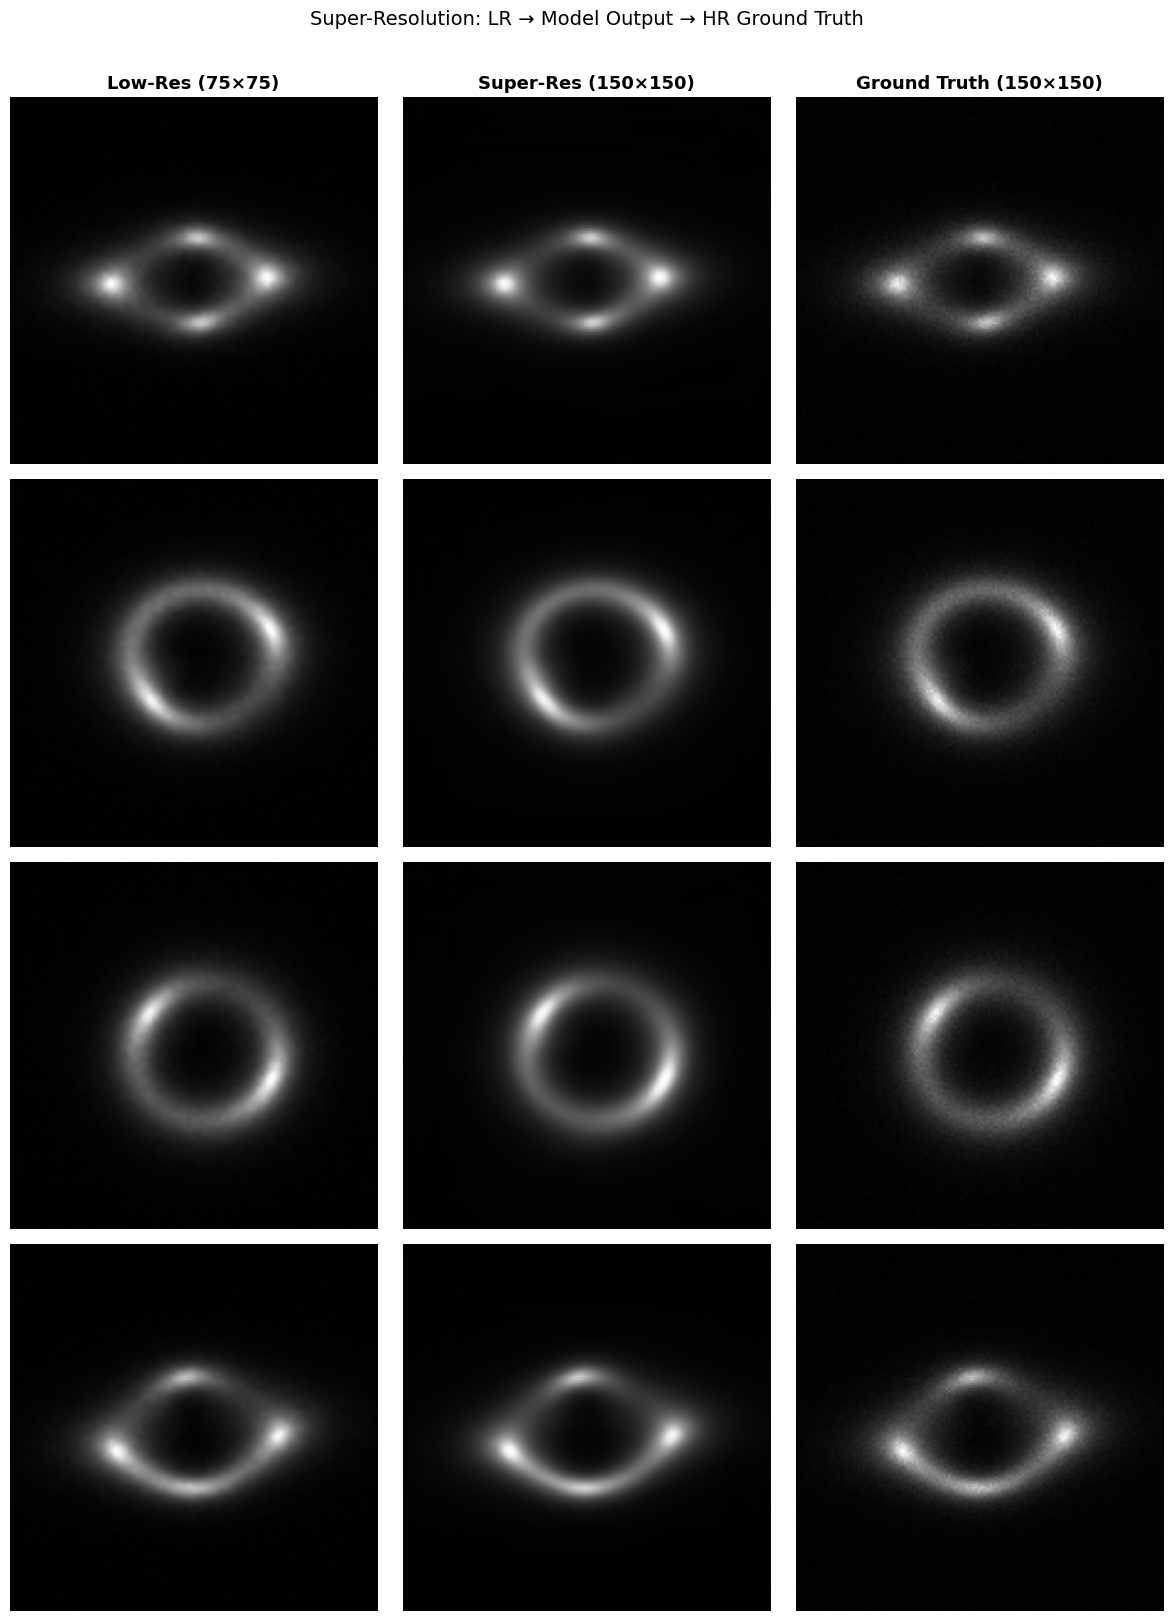

In [ ]:
sr_model.eval()
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
columns = ['Low-Res (75×75)', 'Super-Res (150×150)', 'Ground Truth (150×150)']

for col, title in enumerate(columns):
    axes[0, col].set_title(title, fontsize=13, fontweight='bold')

with torch.no_grad():
    sample_lr, sample_hr = next(iter(test_loader))
    sample_lr, sample_hr = sample_lr[:4].to(device), sample_hr[:4].to(device)
    sample_pred = sr_model(sample_lr)

    for i in range(4):
        # LR (upscaled for display)
        lr_display = F.interpolate(sample_lr[i:i+1], size=(150, 150),
                                    mode='bilinear', align_corners=False)
        axes[i, 0].imshow(lr_display[0, 0].cpu().numpy(), cmap='gray')
        axes[i, 0].axis('off')

        # SR prediction
        axes[i, 1].imshow(sample_pred[i, 0].cpu().numpy(), cmap='gray')
        axes[i, 1].axis('off')

        # HR ground truth
        axes[i, 2].imshow(sample_hr[i, 0].cpu().numpy(), cmap='gray')
        axes[i, 2].axis('off')

plt.suptitle('Super-Resolution: LR → Model Output → HR Ground Truth', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('sr_comparison_test9b.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
torch.save(sr_model.state_dict(), 'mae_super_resolution.pth')
print("Super-resolution model saved!")

Super-resolution model saved!
